# Connectivity Tier Analysis

This notebook is designed for the low-cardinality connectivity setting in this project. Instead of clustering businesses on repeated city-level scores, it:

1. merges the urban connectivity and Yelp business data,
2. creates interpretable connectivity tiers,
3. compares business outcome distributions across tiers, and
4. clusters cities using multiple city-level features.


In [ ]:
import os
import warnings

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


/opt/anaconda3/envs/eda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Load data
urban_path = kagglehub.dataset_download("vellis1/us-cities-urban-connectivity")
yelp_path = kagglehub.dataset_download("yelp-dataset/yelp-dataset")

urban_file = next(f for f in os.listdir(urban_path) if f.endswith(".csv"))
urban_df = pd.read_csv(os.path.join(urban_path, urban_file))
yelp_df = pd.read_json(os.path.join(yelp_path, "yelp_academic_dataset_business.json"), lines=True)

urban_df = urban_df.rename(columns={"City": "city", "State": "state"})

business_cols = [
    "business_id", "name", "city", "state", "stars", "review_count", "is_open",
    "categories", "latitude", "longitude", "postal_code"
]

combined = urban_df.merge(yelp_df[business_cols], on=["city", "state"], how="inner")
combined = combined[combined["is_open"] == 1].copy()
combined["Travel_Score"] = combined[["Walk Score", "Transit Score", "Bike Score"]].mean(axis=1)
combined = combined.drop_duplicates(subset=["business_id"]).copy()

print(f"Urban rows: {urban_df.shape[0]:,}")
print(f"Yelp business rows: {yelp_df.shape[0]:,}")
print(f"Merged open businesses: {combined.shape[0]:,}")
print(f"Matched cities: {combined[['city', 'state']].drop_duplicates().shape[0]}")
print("\nUnique connectivity values by score:")
for score_col in ["Walk Score", "Transit Score", "Bike Score", "Travel_Score"]:
    print(f"  {score_col}: {combined[score_col].nunique()}")


Urban rows: 102
Yelp business rows: 150,346
Merged open businesses: 42,074
Matched cities: 14

Unique connectivity values by score:
  Walk Score: 14
  Transit Score: 14
  Bike Score: 14
  Travel_Score: 14


In [ ]:
def make_tiers(series, labels=("Low", "Medium", "High")):
    """Create quantile tiers with a rank fallback when many duplicate values exist."""
    ranked = series.rank(method="first")
    return pd.qcut(ranked, q=len(labels), labels=labels)

combined["connectivity_tier"] = make_tiers(combined["Travel_Score"])

tier_summary = (
    combined.groupby("connectivity_tier", observed=False)
    .agg(
        businesses=("business_id", "nunique"),
        cities=("city", "nunique"),
        avg_travel_score=("Travel_Score", "mean"),
        avg_stars=("stars", "mean"),
        median_reviews=("review_count", "median")
    )
    .round(2)
)

tier_summary


,businesses,cities,avg_travel_score,avg_stars,median_reviews
connectivity_tier,,,,,
Low,14025,7,35.94,3.70,18.0
Medium,14024,5,48.39,3.64,16.0
High,14025,4,66.11,3.69,19.0


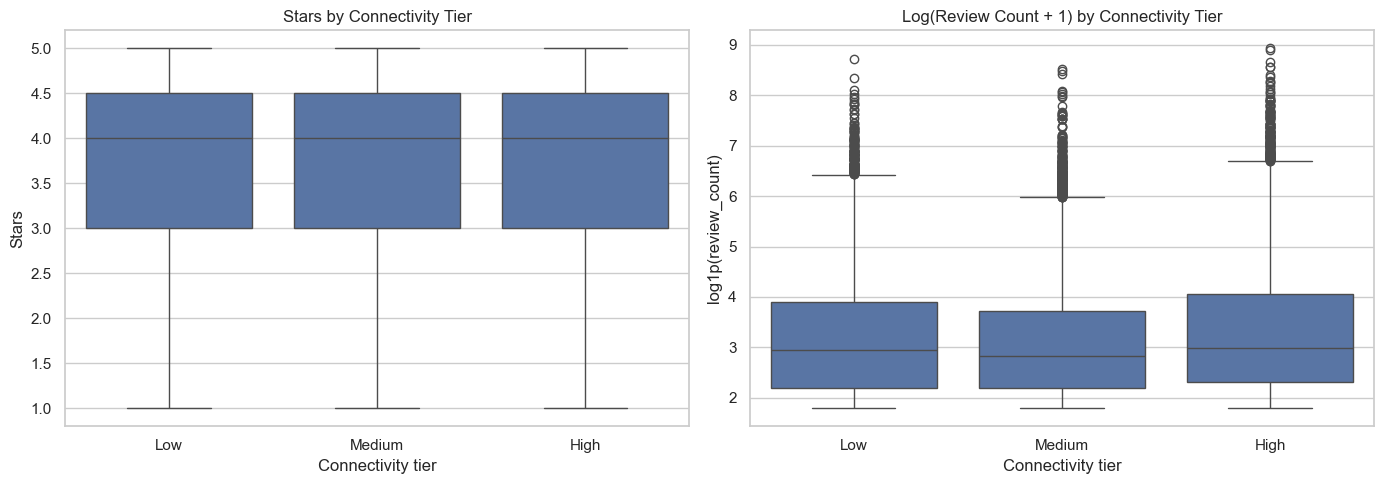

Kruskal-Wallis tests across connectivity tiers
Stars: H=33.535, p=5.224e-08
Review count: H=170.377, p=1.007e-37


In [ ]:
# Distribution checks across connectivity tiers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=combined, x="connectivity_tier", y="stars", ax=axes[0])
axes[0].set_title("Stars by Connectivity Tier")
axes[0].set_xlabel("Connectivity tier")
axes[0].set_ylabel("Stars")

sns.boxplot(data=combined, x="connectivity_tier", y=np.log1p(combined["review_count"]), ax=axes[1])
axes[1].set_title("Log(Review Count + 1) by Connectivity Tier")
axes[1].set_xlabel("Connectivity tier")
axes[1].set_ylabel("log1p(review_count)")

plt.tight_layout()
plt.show()

tier_groups_stars = [g["stars"].values for _, g in combined.groupby("connectivity_tier", observed=False)]
tier_groups_reviews = [g["review_count"].values for _, g in combined.groupby("connectivity_tier", observed=False)]

stars_test = stats.kruskal(*tier_groups_stars)
reviews_test = stats.kruskal(*tier_groups_reviews)

print("Kruskal-Wallis tests across connectivity tiers")
print(f"Stars: H={stars_test.statistic:.3f}, p={stars_test.pvalue:.4g}")
print(f"Review count: H={reviews_test.statistic:.3f}, p={reviews_test.pvalue:.4g}")


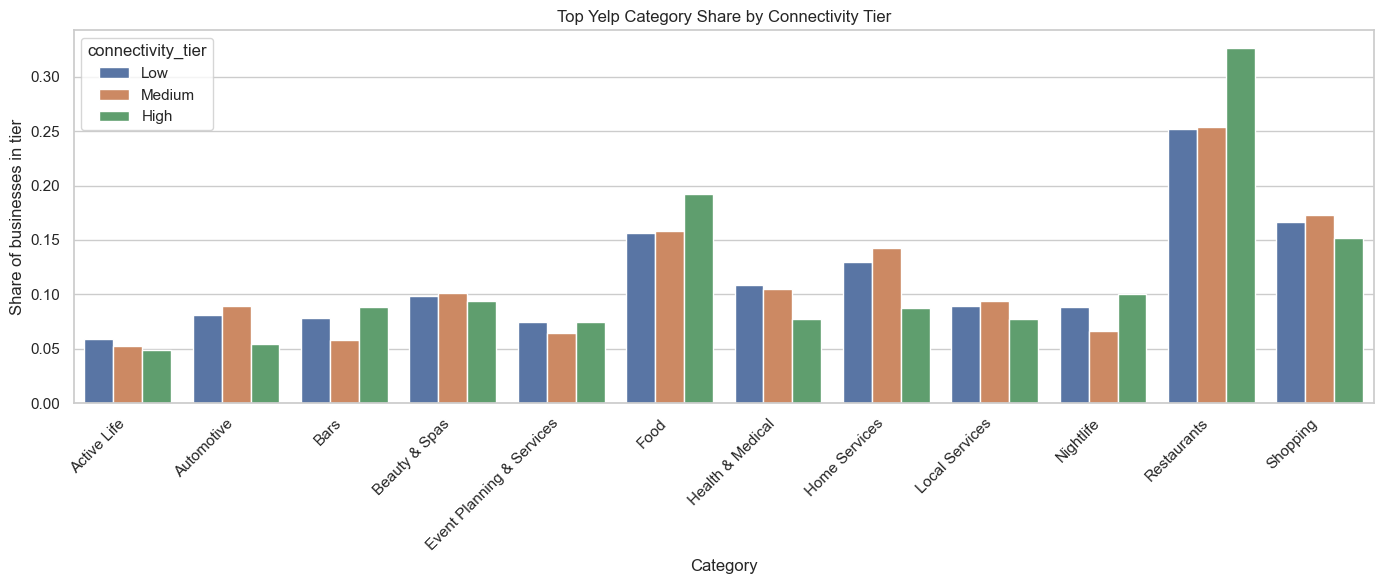

,connectivity_tier,categories,business_count,tier_businesses,share
10,Low,Restaurants,3529,14025,0.251622
11,Low,Shopping,2342,14025,0.166988
5,Low,Food,2198,14025,0.156720
7,Low,Home Services,1823,14025,0.129982
6,Low,Health & Medical,1518,14025,0.108235
3,Low,Beauty & Spas,1376,14025,0.098111
8,Low,Local Services,1247,14025,0.088913
9,Low,Nightlife,1240,14025,0.088414
1,Low,Automotive,1142,14025,0.081426
2,Low,Bars,1093,14025,0.077932


In [ ]:
# Category mix by tier using raw Yelp category labels
category_exploded = combined[["business_id", "connectivity_tier", "categories"]].dropna().copy()
category_exploded["categories"] = category_exploded["categories"].str.split(", ")
category_exploded = category_exploded.explode("categories")

top_categories = category_exploded["categories"].value_counts().head(12).index
category_share = (
    category_exploded[category_exploded["categories"].isin(top_categories)]
    .groupby(["connectivity_tier", "categories"], observed=False)["business_id"]
    .nunique()
    .reset_index(name="business_count")
)

tier_sizes = combined.groupby("connectivity_tier", observed=False)["business_id"].nunique().rename("tier_businesses")
category_share = category_share.merge(tier_sizes, on="connectivity_tier")
category_share["share"] = category_share["business_count"] / category_share["tier_businesses"]

plt.figure(figsize=(14, 6))
sns.barplot(data=category_share, x="categories", y="share", hue="connectivity_tier")
plt.title("Top Yelp Category Share by Connectivity Tier")
plt.xlabel("Category")
plt.ylabel("Share of businesses in tier")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

category_share.sort_values(["connectivity_tier", "share"], ascending=[True, False]).head(20)


In [ ]:
# Cluster cities on multiple city-level features
city_metrics = (
    combined.groupby(["city", "state"]).agg(
        businesses=("business_id", "nunique"),
        avg_stars=("stars", "mean"),
        median_reviews=("review_count", "median"),
        walk_score=("Walk Score", "first"),
        transit_score=("Transit Score", "first"),
        bike_score=("Bike Score", "first"),
        travel_score=("Travel_Score", "first")
    )
    .reset_index()
)

city_metrics["log_businesses"] = np.log1p(city_metrics["businesses"])
city_metrics["log_median_reviews"] = np.log1p(city_metrics["median_reviews"])

cluster_features = [
    "walk_score", "transit_score", "bike_score", "travel_score",
    "avg_stars", "log_businesses", "log_median_reviews"
]

X = city_metrics[cluster_features]
X_scaled = StandardScaler().fit_transform(X)

scores = []
k_values = range(2, min(7, len(city_metrics)))
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    scores.append({"k": k, "silhouette": silhouette_score(X_scaled, labels)})

score_df = pd.DataFrame(scores)
best_k = int(score_df.loc[score_df["silhouette"].idxmax(), "k"])
best_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
city_metrics["cluster"] = best_model.fit_predict(X_scaled)

score_df


,k,silhouette
0,2,0.257675
1,3,0.302774
2,4,0.315073
3,5,0.303959
4,6,0.314100


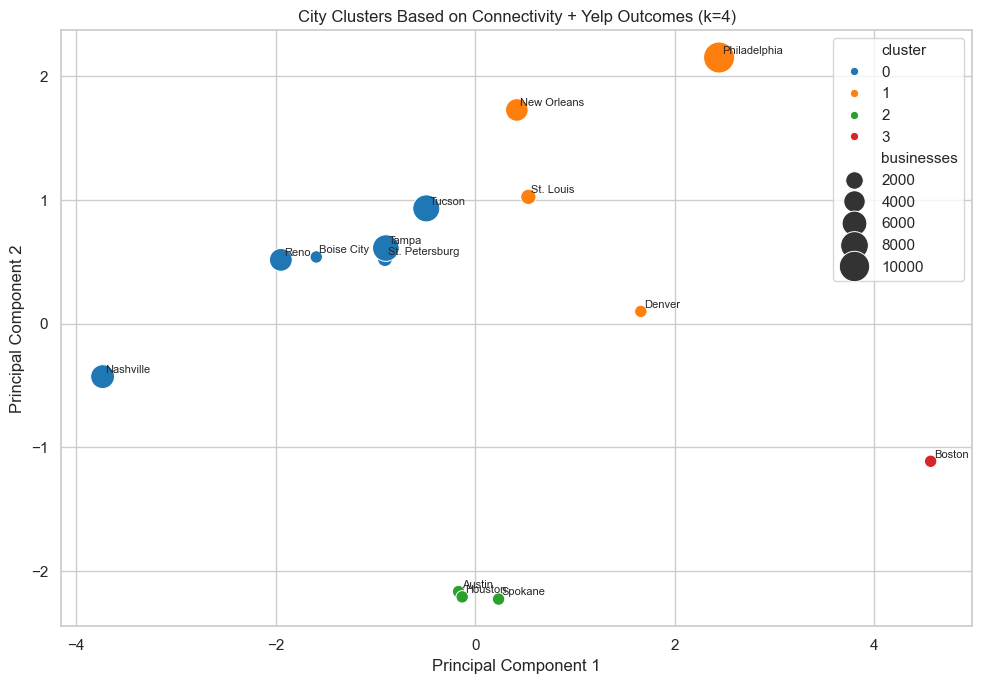

,businesses,avg_stars,median_reviews,walk_score,transit_score,bike_score
cluster,,,,,,
0,4304.67,3.68,20.00,40.53,27.97,54.00
1,4060.50,3.92,16.75,64.92,49.52,65.47
2,1.00,2.00,9.00,46.13,35.67,51.57
3,1.00,1.00,9.00,82.80,72.40,69.40


In [ ]:
# Visualize city clusters in 2D PCA space
pca = PCA(n_components=2, random_state=42)
city_coords = pca.fit_transform(X_scaled)

plot_df = city_metrics.copy()
plot_df["pc1"] = city_coords[:, 0]
plot_df["pc2"] = city_coords[:, 1]
plot_df["city_label"] = plot_df["city"] + ", " + plot_df["state"]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="cluster", size="businesses", sizes=(80, 500), palette="tab10")
for _, row in plot_df.iterrows():
    plt.text(row["pc1"] + 0.03, row["pc2"] + 0.03, row["city"], fontsize=8)
plt.title(f"City Clusters Based on Connectivity + Yelp Outcomes (k={best_k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

cluster_summary = (
    city_metrics.groupby("cluster")[["businesses", "avg_stars", "median_reviews", "walk_score", "transit_score", "bike_score"]]
    .mean()
    .round(2)
)

cluster_summary


## How to interpret this notebook

- If the Kruskal-Wallis `p`-values are small, the business outcome distributions differ across connectivity tiers.
- If the category share plot shifts across tiers, connectivity is associated with different business mixes.
- The city clustering section is more appropriate than clustering individual businesses on repeated city scores because it combines connectivity with outcome and scale variables.
- For a stronger write-up, describe this as exploratory pattern detection rather than causal inference, since connectivity is measured at the city level.
